In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deep-learning-az-ann/Churn_Modelling.csv


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout,ELU,LeakyReLU,PReLU
from sklearn.metrics import accuracy_score

ImportError: Traceback (most recent call last):
  File "c:\Users\Dushyant Yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [ ]:
df=pd.read_csv('JPM.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [33]:
l = LabelEncoder()
df['Geography']=l.fit_transform(df['Geography'])
df['Gender']=l.fit_transform(df['Gender'])

In [34]:
x = df.drop(['RowNumber','CustomerId','Surname','Exited'],axis=1)
y = df['Exited']

In [35]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.fit_transform(xtest)

In [37]:
clf = Sequential()

In [47]:
clf.add(Dense(input_dim=10, units=10, kernel_initializer='he_uniform', activation='relu'))
clf.add(Dropout(0.3))
clf.add(Dense(units=10, kernel_initializer='he_uniform', activation='relu'))
clf.add(Dropout(0.3))
clf.add(Dense(units=10, kernel_initializer='he_uniform', activation='relu'))
clf.add(Dropout(0.3))
clf.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))


clf.compile(optimizer="Adamax",loss='binary_crossentropy',metrics=['accuracy'])

In [49]:
model=clf.fit(xtrain,ytrain,validation_split=0.2,epochs=400,batch_size=10)

Epoch 1/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7615 - loss: 0.5841 - val_accuracy: 0.7987 - val_loss: 0.5132
Epoch 2/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7965 - loss: 0.5480 - val_accuracy: 0.7987 - val_loss: 0.5189
Epoch 3/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7890 - loss: 0.5370 - val_accuracy: 0.7987 - val_loss: 0.5119
Epoch 4/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7878 - loss: 0.5451 - val_accuracy: 0.7987 - val_loss: 0.5111
Epoch 5/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7894 - loss: 0.5315 - val_accuracy: 0.7987 - val_loss: 0.5138
Epoch 6/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7937 - loss: 0.5263 - val_accuracy: 0.7987 - val_loss: 0.5114
Epoch 7/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8039 - loss: 0.5079 - val_accuracy: 0.7987 - val_loss: 0.5124
Epoch 8/400
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7923 - loss: 0.5193 - val_acc

In [54]:
yp=clf.predict(xtest)
yp=yp>0.5
print(yp)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[False]
 [False]
 [False]
 ...
 [False]
 [False]
 [False]]


In [56]:
score=accuracy_score(yp,ytest)
score

0.8035

In [57]:
clf.save("BankExit_predict.h5")

In [74]:
a=np.array([[1000,2,1,32,1,0,1,0,0,200000]])
pp=clf.predict(a)>0.5;
pp

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[False]])

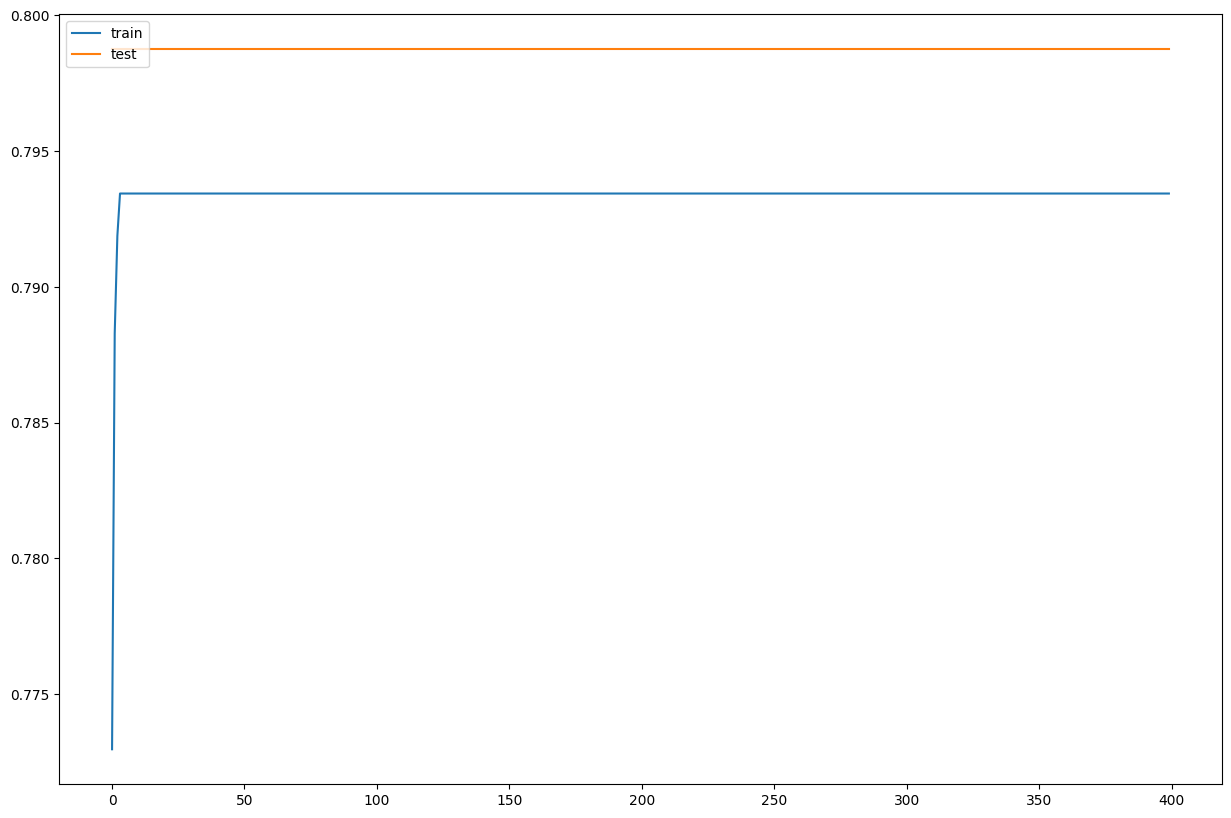

In [73]:
plt.figure(figsize=(15,10))

# plt.plot(model.history['loss'])
plt.plot(model.history['accuracy'])
plt.plot(model.history['val_accuracy'])
plt.legend(['train','test'],loc='upper left')
plt.show()